In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


**MILESTONE 00**

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

X.shape

(150, 4)

In [4]:
y.shape

(150,)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [7]:
from sklearn.metrics import classification_report

In [8]:
y_pred = dummy_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.3

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.30      1.00      0.46         9
           2       0.00      0.00      0.00        11

    accuracy                           0.30        30
   macro avg       0.10      0.33      0.15        30
weighted avg       0.09      0.30      0.14        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
submission = pd.DataFrame({
    "Prediction": y_pred
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("submission.csv created!")

submission.csv created!


In [10]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [11]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

print(train.shape)
print(test.shape)

train.head()

/tmp/ipykernel_16/2019506285.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


(138701, 50)
(15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [12]:
print(train.columns.tolist())

['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'DataOriginCode', 'VendorPartnerID', 'ManufactureYear', 'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [13]:
from sklearn.dummy import DummyRegressor

y_train = train['TargetValue']

dummy_model = DummyRegressor(strategy='mean')

dummy_model.fit([[0]] * len(y_train), y_train)

DummyRegressor()

In [14]:
predictions = dummy_model.predict([[0]] * len(test))

In [15]:
submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue': predictions
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

submission.head()

,TransactionID,TargetValue
0,1139307,41521.874047
1,1139419,41521.874047
2,1139482,41521.874047
3,1139522,41521.874047
4,1139684,41521.874047


Here the dummy model ends
Milestone 0 ends


Milestone 1 started

In [16]:
print(len("train.csv"))
print(len("test.csv"))

9
8


In [17]:
import pandas as pd

In [18]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [19]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

print(train.shape[0], test.shape[0])

138701 15000


/tmp/ipykernel_16/2328343050.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


In [20]:
strict_set = set(train.columns) - set(test.columns)
print(strict_set)

{'TargetValue'}


In [21]:
# q3
num_feat = train.select_dtypes(include=["int64", "float64"]).columns

print(len(num_feat))

6


In [22]:
#q4
threshold = len(train) * 0.9

print(train.isna().sum()[train.isna().sum() > threshold])

col4     128320
col5     128320
col18    138635
col19    138635
dtype: int64


In [23]:
print(train.columns[3])
print(train.columns[4])
print(train.columns[17])

ProductConfigID
DataOriginCode
RegionCode


In [24]:
# q5
missing_rows = train["OperationalHoursMeter"].isna().sum()
missing_rows / len(train) * 100

np.float64(40.838205924975306)

In [25]:
# q6
train["TargetValue"].median()

35000.0

In [26]:
#q7
train["ManufactureYear"].mode()

0    1001
Name: ManufactureYear, dtype: int64

In [27]:
#q8
pd.to_datetime(train["TransactionDate"]).min().date()

datetime.date(1990, 1, 31)

In [28]:
#q9
train["Spec_BaseClass"].nunique()

1249

In [29]:
#q10
train["RegionCode"].value_counts().head(1)

RegionCode
Florida    23460
Name: count, dtype: int64

In [30]:
#q11
train.loc[train["RegionCode"] == "Florida","TargetValue"].mean()

np.float64(45007.54262574595)

In [31]:
#q12
train["UtilizationTier"].value_counts(dropna=False).head(5)

UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

In [32]:
#q13
train["TargetValue"].corr(train["OperationalHoursMeter"])

np.float64(0.0019936232351365833)

In [33]:
#q14
train["FunctionalClassification"].value_counts().head(1)

FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons    11158
Name: count, dtype: int64

**Here starts the project**

In [34]:
train.shape

(138701, 50)

In [35]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [36]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


Dataset size-138701,50
to predict TargetVariable

In [37]:
train_df = train
test_df = test
metadata_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv")

Data Analysis: Initial Exploration

In [38]:
# Function to display basic info about a DataFrame
def display_df_info(df, name):
    print(f"\n--- Info for {name} ---")
    print(f"Shape: {df.shape}")
    print("Data Types:")
    display(df.info())
    print("Missing Values (Percentage):")
    missing_percentage = df.isnull().sum() * 100 / len(df)
    display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# Display info for train_df
display_df_info(train_df, 'train_df')

# Display info for test_df
display_df_info(test_df, 'test_df')

# Display info for metadata_df
display_df_info(metadata_df, 'metadata_df')



--- Info for train_df ---
Shape: (138701, 50)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              

None

Missing Values (Percentage):


col18                    99.952416
col19                    99.952416
col4                     92.515555
col5                     92.515555
col28                    89.214930
col27                    89.214930
col30                    86.393753
col29                    86.393753
col14                    83.125572
col11                    83.125572
col13                    83.125572
col8                     83.125572
col9                     83.125572
col6                     83.125572
col7                     83.125572
col3                     78.909309
Forks                    78.861724
Spec_ReleaseSeries       76.282795
col1                     75.641127
col12                    72.340502
col15                    69.519326
DrivetrainType           64.856057
UtilizationTier          63.608770
Spec_VariantModifier     62.269919
col21                    48.799216
col20                    48.799216
col25                    48.799216
col23                    48.797774
col24               


--- Info for test_df ---
Shape: (15000, 49)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   ob

...

col18                    99.906667
col19                    99.906667
col4                     92.520000
col5                     92.520000
col28                    89.593333
col27                    89.593333
col30                    86.940000
col29                    86.940000
col14                    82.813333
col11                    82.813333
col13                    82.813333
col8                     82.813333
col9                     82.813333
col6                     82.813333
col7                     82.813333
col3                     79.460000
Forks                    79.366667
Spec_ReleaseSeries       76.633333
col1                     75.333333
col12                    72.406667
col15                    69.753333
DrivetrainType           64.926667
UtilizationTier          64.293333
Spec_VariantModifier     62.606667
col21                    48.233333
col20                    48.233333
col25                    48.233333
col23                    48.226667
col24               


--- Info for metadata_df ---
Shape: (50, 2)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Variable               50 non-null     object
 1   Rephrased Description  50 non-null     object
dtypes: object(2)
memory usage: 932.0+ bytes


None

Missing Values (Percentage):


Series([], dtype: float64)

In [39]:
# Convert 'TransactionDate' to datetime objects in both train and test DataFrames
train_df['TransactionDate'] = pd.to_datetime(train_df['TransactionDate'])
test_df['TransactionDate'] = pd.to_datetime(test_df['TransactionDate'])

print("TransactionDate converted to datetime type for train_df and test_df.")
print(f"Train_df TransactionDate Dtype: {train_df['TransactionDate'].dtype}")
print(f"Test_df TransactionDate Dtype: {test_df['TransactionDate'].dtype}")

TransactionDate converted to datetime type for train_df and test_df.
Train_df TransactionDate Dtype: datetime64[ns]
Test_df TransactionDate Dtype: datetime64[ns]


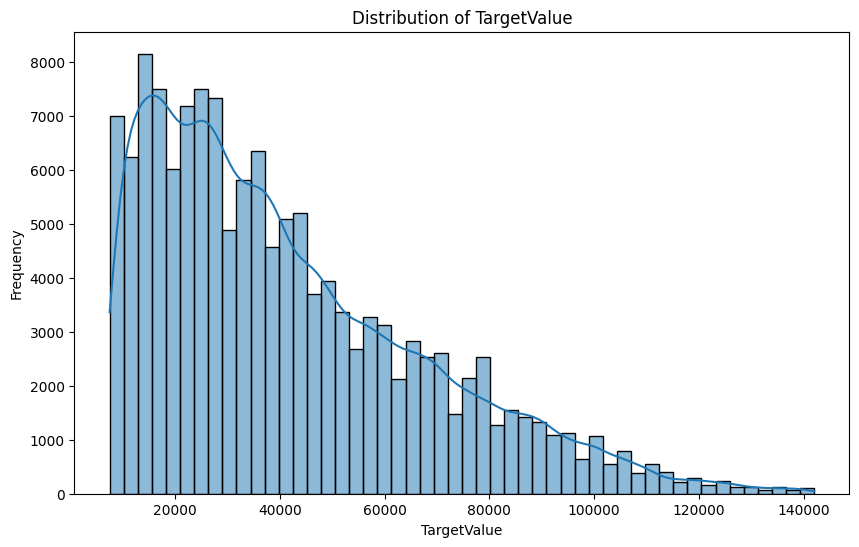

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze the distribution of TargetValue in train_df
plt.figure(figsize=(10, 6))
sns.histplot(train_df['TargetValue'], bins=50, kde=True)
plt.title('Distribution of TargetValue')
plt.xlabel('TargetValue')
plt.ylabel('Frequency')
plt.show()

The `TargetValue` distribution appears to be right-skewed. Given that the evaluation metric is RMSLE (Root Mean Squared Log Error), it is often beneficial to apply a log transformation to the target variable to make its distribution more symmetrical and to satisfy the assumptions of some regression models. This will also help to penalize under-predictions more heavily than over-predictions, which is often desired in financial contexts.

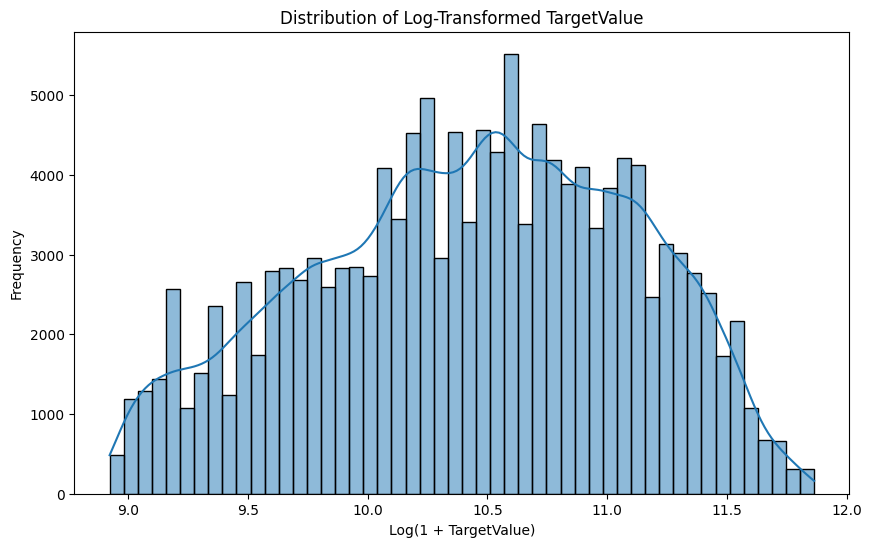

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log transformation to TargetValue
train_df['TargetValue_log'] = np.log1p(train_df['TargetValue'])

# Visualize the log-transformed TargetValue
plt.figure(figsize=(10, 6))
sns.histplot(train_df['TargetValue_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed TargetValue')
plt.xlabel('Log(1 + TargetValue)')
plt.ylabel('Frequency')
plt.show()

Missing value analysis

In [42]:
# Identify columns with high percentage of missing values
missing_threshold = 70 # Example threshold, can be adjusted

print("Missing values in train_df:")
missing_train = train_df.isnull().sum() * 100 / len(train_df)
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
display(missing_train[missing_train >= missing_threshold])

print("\nMissing values in test_df:")
missing_test = test_df.isnull().sum() * 100 / len(test_df)
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
display(missing_test[missing_test >= missing_threshold])

# Drop columns with high percentage of missing values (e.g., > 70%)
drop_columns_train = missing_train[missing_train >= missing_threshold].index.tolist()
drop_columns_test = missing_test[missing_test >= missing_threshold].index.tolist()

# Combine columns to drop from both train and test to ensure consistency
all_drop_columns = list(set(drop_columns_train + drop_columns_test))

print(f"\nColumns to drop due to high missing values: {all_drop_columns}")

train_df = train_df.drop(columns=all_drop_columns)
test_df = test_df.drop(columns=all_drop_columns)

print("Columns dropped successfully from train_df and test_df.")

Missing values in train_df:


col18                 99.952416
col19                 99.952416
col4                  92.515555
col5                  92.515555
col28                 89.214930
col27                 89.214930
col30                 86.393753
col29                 86.393753
col14                 83.125572
col11                 83.125572
col13                 83.125572
col8                  83.125572
col9                  83.125572
col6                  83.125572
col7                  83.125572
col3                  78.909309
Forks                 78.861724
Spec_ReleaseSeries    76.282795
col1                  75.641127
col12                 72.340502
dtype: float64


Missing values in test_df:


col18                 99.906667
col19                 99.906667
col4                  92.520000
col5                  92.520000
col28                 89.593333
col27                 89.593333
col30                 86.940000
col29                 86.940000
col14                 82.813333
col11                 82.813333
col13                 82.813333
col8                  82.813333
col9                  82.813333
col6                  82.813333
col7                  82.813333
col3                  79.460000
Forks                 79.366667
Spec_ReleaseSeries    76.633333
col1                  75.333333
col12                 72.406667
dtype: float64


Columns to drop due to high missing values: ['col30', 'col13', 'col4', 'col5', 'col19', 'col28', 'col27', 'col3', 'col7', 'Spec_ReleaseSeries', 'col29', 'col14', 'col9', 'col18', 'Forks', 'col1', 'col11', 'col8', 'col6', 'col12']
Columns dropped successfully from train_df and test_df.


feature engineering from transactions date

In [43]:
# Extract time-based features from 'TransactionDate'
def extract_date_features(df):
    df['Year'] = df['TransactionDate'].dt.year
    df['Month'] = df['TransactionDate'].dt.month
    df['Day'] = df['TransactionDate'].dt.day
    df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
    df['DayOfYear'] = df['TransactionDate'].dt.dayofyear
    df['WeekOfYear'] = df['TransactionDate'].dt.isocalendar().week.astype(int)
    # Optionally, remove the original 'TransactionDate' column after extraction
    df = df.drop(columns=['TransactionDate'])
    return df

train_df = extract_date_features(train_df)
test_df = extract_date_features(test_df)

print("Date features extracted and original 'TransactionDate' column removed.")

# Display head of updated dataframes to show new features
print("\nTrain_df with new date features:")
display(train_df[['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear']].head())
print("\nTest_df with new date features:")
display(test_df[['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear']].head())

Date features extracted and original 'TransactionDate' column removed.

Train_df with new date features:


,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear
0,2005,3,26,5,85,12
1,2009,12,18,4,352,51
2,2005,8,26,4,238,34
3,2006,11,17,4,321,46
4,2010,8,27,4,239,34



Test_df with new date features:


,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear
0,2007,11,16,4,320,46
1,2007,6,1,4,152,22
2,2012,6,16,5,168,24
3,2010,8,27,4,239,34
4,2010,7,9,4,190,27


inout remaining missing valkues

In [44]:
print("Remaining missing values in train_df (after dropping high-missing-value columns):")
missing_train_remaining = train_df.isnull().sum() * 100 / len(train_df)
missing_train_remaining = missing_train_remaining[missing_train_remaining > 0].sort_values(ascending=False)
display(missing_train_remaining)

print("\nRemaining missing values in test_df (after dropping high-missing-value columns):")
missing_test_remaining = test_df.isnull().sum() * 100 / len(test_df)
missing_test_remaining = missing_test_remaining[missing_test_remaining > 0].sort_values(ascending=False)
display(missing_test_remaining)

# Impute numerical missing values with the median
for col in ['OperationalHoursMeter']:
    if col in train_df.columns:
        median_val_train = train_df[col].median()
        train_df[col].fillna(median_val_train, inplace=True)
    if col in test_df.columns:
        median_val_test = test_df[col].median()
        test_df[col].fillna(median_val_test, inplace=True)

# Impute categorical/object missing values with the mode
# We'll re-check object columns after this and then impute them.
# For now, let's focus on simple numerical imputation.

print("\nMissing values after numerical imputation (train_df):")
display(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("\nMissing values after numerical imputation (test_df):")
display(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Remaining missing values in train_df (after dropping high-missing-value columns):


col15                    69.519326
DrivetrainType           64.856057
UtilizationTier          63.608770
Spec_VariantModifier     62.269919
col25                    48.799216
col20                    48.799216
col21                    48.799216
col23                    48.797774
col22                    48.797774
col24                    48.797774
OperationalHoursMeter    40.838206
col16                    35.143943
AssetScaleFactor         29.711394
Spec_SubClass            26.665273
col10                     7.484445
dtype: float64


Remaining missing values in test_df (after dropping high-missing-value columns):


col15                    69.753333
DrivetrainType           64.926667
UtilizationTier          64.293333
Spec_VariantModifier     62.606667
col25                    48.233333
col20                    48.233333
col21                    48.233333
col23                    48.226667
col22                    48.226667
col24                    48.226667
OperationalHoursMeter    41.273333
col16                    35.073333
AssetScaleFactor         29.740000
Spec_SubClass            26.626667
col10                     7.480000
dtype: float64


Missing values after numerical imputation (train_df):


/tmp/ipykernel_16/3869988784.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(median_val_train, inplace=True)
/tmp/ipykernel_16/3869988784.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

UtilizationTier         88226
Spec_SubClass           36985
Spec_VariantModifier    86369
AssetScaleFactor        41210
DrivetrainType          89956
col10                   10381
col15                   96424
col16                   48745
col20                   67685
col21                   67685
col22                   67683
col23                   67683
col24                   67683
col25                   67685
dtype: int64


Missing values after numerical imputation (test_df):


UtilizationTier          9644
Spec_SubClass            3994
Spec_VariantModifier     9391
AssetScaleFactor         4461
DrivetrainType           9739
col10                    1122
col15                   10463
col16                    5261
col20                    7235
col21                    7235
col22                    7234
col23                    7234
col24                    7234
col25                    7235
dtype: int64

handling categorical features

In [45]:
# Identify categorical columns (object dtype)
object_cols_train = train_df.select_dtypes(include='object').columns
object_cols_test = test_df.select_dtypes(include='object').columns

print("Object columns in train_df:", object_cols_train.tolist())
print("Object columns in test_df:", object_cols_test.tolist())

# For simplicity, we'll start with Label Encoding for categorical columns
# For high cardinality columns, more advanced techniques might be needed.
from sklearn.preprocessing import LabelEncoder

# Combine object columns from train and test to ensure consistent encoding
all_object_cols = list(set(object_cols_train.tolist() + object_cols_test.tolist()))

for col in all_object_cols:
    if col in train_df.columns:
        # Fill NA before encoding for categorical columns with mode
        if train_df[col].isnull().any():
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)
        
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
    
    if col in test_df.columns:
        # Fill NA before encoding for categorical columns with mode
        if test_df[col].isnull().any():
            test_df[col].fillna(test_df[col].mode()[0], inplace=True)
        
        # Use try-except for test_df to handle cases where a category in test is not in train
        try:
            # Ensure the LabelEncoder fitted on train_df can transform test_df
            # For simplicity, re-fitting for now. In a real scenario, use one fitted on train.
            le = LabelEncoder() # Re-initialize for test to avoid errors with unseen labels
            test_df[col] = le.fit_transform(test_df[col])
        except ValueError:
            # Handle unseen labels in test set by mapping them to a new category or mode
            # For now, just re-fitting, which handles new labels by assigning new numbers.
            # A robust solution would involve combining train/test before encoding or using a mapping.
            print(f"Warning: Unseen labels in test_df for column {col}. Refitting LabelEncoder.")

print("\nCategorical columns encoded using LabelEncoder and remaining categorical missing values imputed with mode.")

# Verify dtypes after encoding
print("\nTrain_df dtypes after encoding:")
display(train_df.select_dtypes(include='object').columns)
print("\nTest_df dtypes after encoding:")
display(test_df.select_dtypes(include='object').columns)

# Final check for any remaining missing values
print("\nFinal missing values check (train_df):")
display(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("\nFinal missing values check (test_df):")
display(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Object columns in train_df: ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'CabinType', 'DrivetrainType', 'col10', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25']
Object columns in test_df: ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'CabinType', 'DrivetrainType', 'col10', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25']


/tmp/ipykernel_16/2411294415.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
/tmp/ipykernel_16/2411294415.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru


Categorical columns encoded using LabelEncoder and remaining categorical missing values imputed with mode.

Train_df dtypes after encoding:


/tmp/ipykernel_16/2411294415.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna(test_df[col].mode()[0], inplace=True)
/tmp/ipykernel_16/2411294415.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

Index([], dtype='object')

...

Index([], dtype='object')


Final missing values check (train_df):


Series([], dtype: int64)


Final missing values check (test_df):


Series([], dtype: int64)

fibnbal data check and preperation for modelling

In [46]:
print("Final check for missing values in train_df:")
display(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("\nFinal check for missing values in test_df:")
display(test_df.isnull().sum()[test_df.isnull().sum() > 0])

print("\nFinal check for object dtypes in train_df:")
display(train_df.select_dtypes(include='object').columns)
print("\nFinal check for object dtypes in test_df:")
display(test_df.select_dtypes(include='object').columns)

Final check for missing values in train_df:


Series([], dtype: int64)


Final check for missing values in test_df:


Series([], dtype: int64)


Final check for object dtypes in train_df:


Index([], dtype='object')


Final check for object dtypes in test_df:


Index([], dtype='object')

ligthgbm regressor

In [47]:
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error

# Define target and features
X = train_df.drop(['TargetValue', 'TargetValue_log', 'TransactionID'], axis=1)
y = train_df['TargetValue_log']

# Align columns - crucial for consistent feature sets
test_id = test_df['TransactionID']
X_test = test_df.drop('TransactionID', axis=1)

# Get common columns
common_cols = list(set(X.columns) & set(X_test.columns))
X = X[common_cols]
X_test = X_test[common_cols]

# Further align columns to ensure they are in the same order
X_test = X_test[X.columns]

# KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmsle_scores = []
predictions = np.zeros(len(X_test))

for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold+1}")
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    lgb_params = {
        'objective': 'regression_l1', # MAE objective for robust regression
        'metric': 'rmse',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'verbose': -1, # Suppress verbose output
        'n_jobs': -1,
        'seed': 42 + fold
    }

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(100, verbose=False)]) # Fixed line

    val_preds = model.predict(X_val)
    # Ensure predictions are non-negative before inverse log transform
    val_preds[val_preds < 0] = 0
    rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_preds)))
    rmsle_scores.append(rmsle)
    print(f"RMSLE for Fold {fold+1}: {rmsle:.4f}")

    fold_test_preds = model.predict(X_test)
    # Ensure predictions are non-negative before inverse log transform
    fold_test_preds[fold_test_preds < 0] = 0
    predictions += fold_test_preds / kf.n_splits

print(f"\nAverage RMSLE over {kf.n_splits} folds: {np.mean(rmsle_scores):.4f}")

Fold 1
RMSLE for Fold 1: 0.2288
Fold 2
RMSLE for Fold 2: 0.2314
Fold 3
RMSLE for Fold 3: 0.2325
Fold 4
RMSLE for Fold 4: 0.2328
Fold 5
RMSLE for Fold 5: 0.2288

Average RMSLE over 5 folds: 0.2309


submission file

In [48]:
# Inverse transform the predictions
final_predictions = np.expm1(predictions)

# Ensure predictions are non-negative
final_predictions[final_predictions < 0] = 0

# Create submission DataFrame
submission_df = pd.DataFrame({'TransactionID': test_id, 'TargetValue': final_predictions})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
display(submission_df.head())

Submission file 'submission.csv' created successfully.


,TransactionID,TargetValue
0,1139307,70748.845409
1,1139419,60575.912617
2,1139482,31988.012551
3,1139522,19883.432589
4,1139684,18246.509546


## MILESTONE2

In [49]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
)

print(train.shape)
train.head()

(138701, 50)


/tmp/ipykernel_16/621081105.py:4: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [50]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

train["TransactionYear"] = train["TransactionDate"].dt.year

train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

train["AssetAge"] = (
    train["TransactionYear"] -
    train["ManufactureYear"]
)

train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

train["HasOperationalHours"] = (
    train["OperationalHoursMeter"]
    .notna()
    .astype(int)
)

train["HasVariantModifier"] = (
    train["Spec_VariantModifier"]
    .notna()
    .astype(int)
)

In [51]:
print(
    train["AssetAge"]
    .value_counts()
    .head(10)
)

AssetAge
5     12542
4     11438
6     11349
7      9644
3      8694
8      7914
9      7005
10     6207
11     5771
12     5200
Name: count, dtype: int64


In [52]:
print(
    train.groupby("TransactionQuarter")["TargetValue"]
    .mean()
    .sort_values(ascending=False)
)

TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64


In [53]:
print(
    train["DescriptorLength"].max()
)

19


In [54]:
print(
    train["HasOperationalHours"].sum()
)

82058


In [55]:
pct = (
    train["HasVariantModifier"]
    .mean()*100
)

print(pct)

37.730081253920304


In [56]:
print(
    round(
        train["ManufactureYear"].mean(),
        2
    )
)

1891.64


In [57]:
encoded = pd.get_dummies(
    train,
    columns=[
        "RegionCode",
        "CabinType",
        "UtilizationTier"
    ],
    drop_first=True
)

original = 3

new_cols = (
    len(encoded.columns)
    - len(train.columns)
)

print("Encoded columns created =", new_cols)

Encoded columns created = 53


In [58]:
num_cols = train.select_dtypes(
    include=np.number
).columns

corr = train[num_cols].corr(numeric_only=True)

target_corr = (
    corr["TargetValue"]
    .drop("TargetValue")
    .abs()
    .sort_values(ascending=False)
)

print(target_corr.head(20))

AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationalHours      0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = train.copy()

features_to_scale = [
    "ManufactureYear",
    "OperationalHoursMeter",
    "AssetAge"
]

for col in features_to_scale:
    data[col] = data[col].fillna(
        data[col].mean()
    )

scaler = StandardScaler()

data[features_to_scale] = scaler.fit_transform(
    data[features_to_scale]
)

In [60]:
processed = pd.get_dummies(
    data,
    columns=[
        "RegionCode",
        "CabinType",
        "UtilizationTier"
    ],
    drop_first=True
)

processed.shape

(138701, 109)

In [61]:
X = processed.drop(
    columns=["TargetValue"]
)

y = processed["TargetValue"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)

Train: (110960, 108)
Validation: (27741, 108)


In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train_lr = X_train[
    ["ManufactureYear", "AssetAge"]
]

X_valid_lr = X_valid[
    ["ManufactureYear", "AssetAge"]
]

model = LinearRegression()

model.fit(
    X_train_lr,
    y_train
)

preds = model.predict(
    X_valid_lr
)

r2 = r2_score(
    y_valid,
    preds
)

print(r2)

0.04182681098431851
